In [1]:
#Process a single image

In [2]:
# -*- coding: utf-8 -*-# 

# Import the base python packages needed for this notebook
import numpy                                                          as np
import xarray                                                         as xr
import scipy
import re
import os
import subprocess
from   pathlib                    import Path
from   urllib.request             import urlretrieve
import zipfile
%matplotlib inline
import matplotlib                                                     as mpl
import matplotlib.pyplot                                              as plt
import matplotlib.patches                                             as patches
from   matplotlib                 import ticker
from   matplotlib.colors          import LogNorm
import sys
# Get the parent directory path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Insert it at the beginning of the path list so Python checks it first
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
    
# Supressing tensorflow based warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=UserWarning)
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
logging.getLogger('tensorflow_probability').setLevel(logging.ERROR)

# Import some specific functions and packages from MDN implementation
from   MDN                        import download_example_imagery, print_available_imagery, export_dataset, IMAGERY_REGISTRY
from   MDN                        import display_sat_rgb, get_sensor_bands, extract_satellite_data, overlay_rgb_mdn_preds_limits, fix_geo_orientation
from   MDN                        import extract_satellite_data, get_sensor_bands, translate_wavelengths_to_landsat_bands, map_cube_mdn

# Set display parameters via MATPLOTLIB for this notebook
plt.rcParams.update({"text.usetex": False,})
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

plt.rcParams['mathtext.default'] = 'regular'
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16
mrkSize = 15
ASPECT = "auto"
cmap = "jet"

mpl.rcParams['xtick.labelsize'] = SMALL_SIZE
mpl.rcParams['ytick.labelsize'] = SMALL_SIZE

plt.rc('font', size=SMALL_SIZE)  # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)  # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)


[compat_patch] NumPy version: 2.3.3
[compat_patch] Applied NumPy _randomstate_ctor patch.
[compat_patch] TensorFlow version: 2.20.0
[compat_patch] Applied TensorFlow TrackableReference patch (tracking.base).
[compat_patch] NumPy version: 2.3.3
[compat_patch] TensorFlow version: 2.20.0
Modified RC Params: dict_keys(['backend_fallback', 'interactive'])


In [3]:
%matplotlib inline
# ==============================================================================
# EXERCISE: Download & Inspect PACE Scene over Lake Erie (05/31/2024)
# ==============================================================================

# TODO: Fill in the parameters for your tile_path, sensor, and desired products
sensor   = "PACE-delivery"

products = "chl"
date     = "06-12-2024"
location = "Lake Erie"

# use PACE example image just to test sensor model functionality as it is hyperspectral
tile_path = download_example_imagery(sensor='PACE', date=date, location=location)



🔄 Detected North-South flip. Reversing dimension.
NetCDF file source detected. Delegating to extract_netcdf_satellite_rrs for sensor PACE-delivery: sat_cube.nc
Hierarchical group schema detected. Accessing nested groups.
Extracted/Assigned Dataset CRS: EPSG:4326
Auto-detected variable type: RRS
Selected variables: ['Rrs_410', 'Rrs_415', 'Rrs_420', 'Rrs_425', 'Rrs_430', 'Rrs_435', 'Rrs_440', 'Rrs_445', 'Rrs_450', 'Rrs_455', 'Rrs_460', 'Rrs_465', 'Rrs_470', 'Rrs_475', 'Rrs_480', 'Rrs_485', 'Rrs_490', 'Rrs_495', 'Rrs_500', 'Rrs_505', 'Rrs_510', 'Rrs_515', 'Rrs_520', 'Rrs_525', 'Rrs_530', 'Rrs_535', 'Rrs_540', 'Rrs_545', 'Rrs_550', 'Rrs_555', 'Rrs_560', 'Rrs_565', 'Rrs_570', 'Rrs_575', 'Rrs_580', 'Rrs_586', 'Rrs_591', 'Rrs_615', 'Rrs_620', 'Rrs_625', 'Rrs_630', 'Rrs_635', 'Rrs_640', 'Rrs_645', 'Rrs_650', 'Rrs_655', 'Rrs_660', 'Rrs_665', 'Rrs_670', 'Rrs_675', 'Rrs_679', 'Rrs_684', 'Rrs_689', 'Rrs_694', 'Rrs_699', 'Rrs_704', 'Rrs_709', 'Rrs_714', 'Rrs_719']
Output spectral shape: (59, 175, 1

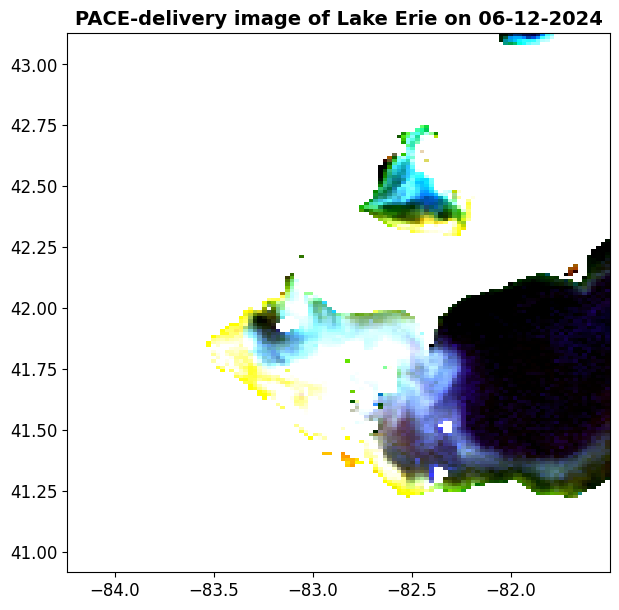

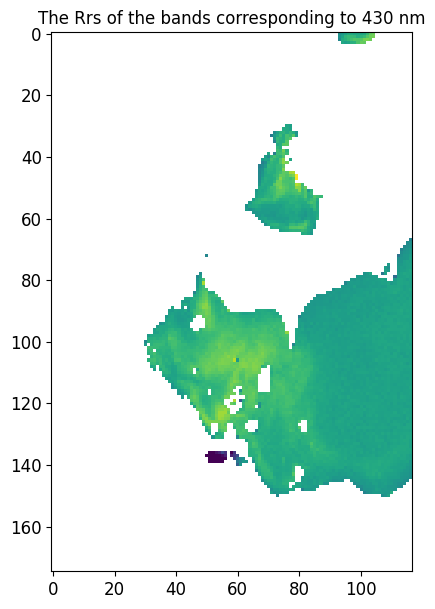

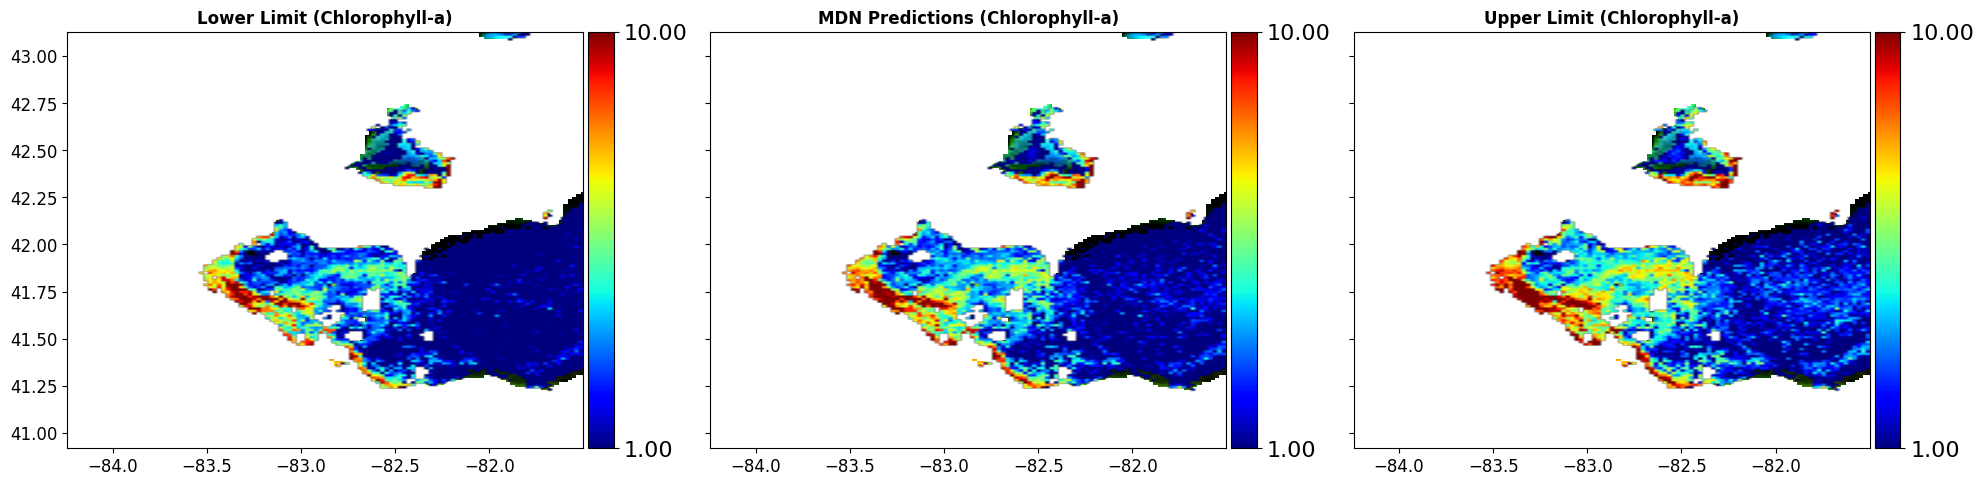

In [4]:

######################################################################################
# Open the NetCDF dataset lazily using xarray
ds = xr.open_dataset(tile_path)

#TODO: now display the RGB of the downloaded tile -- this will use the rhos data from the NetCDF file to create a true color image
img_rgb = display_sat_rgb(tile_path, sensor, figsize=(7,7), title=f"{sensor} image of {location} on {date}", ipython_mode=True,use_rhos=False)

# TODO Let us now extract the Rrs data
bands = get_sensor_bands(sensor)
da = extract_satellite_data(tile_path, sensor=sensor, bands=bands, wavelength_unit="nm", verbose=True, flag_toa=False, chunk_size=100)
da = fix_geo_orientation(da)

# Display the results - for the first band
fig1, ax1 = plt.subplots(figsize=(7,7))
fig1.patch.set_visible(True)

bnd= 4
img1 = ax1.imshow(da.isel(band=bnd), cmap="viridis")
ax1.set_title(f'The Rrs of the bands corresponding to {bands[bnd]} nm');

# Generate MDN predictions for this dataset
map_preds, op_slices = map_cube_mdn(da, sensor=sensor, products=products, return_uncert=True, uncert_mode="limits", scaler_mode="invert", progress_vis=True)

# Get the extent from the data
extent = map_preds.attrs['extent']
product = "chl"
str1 = f"Chlorophyll-a"
fig1 = overlay_rgb_mdn_preds_limits(rgb_img= img_rgb, model_preds = map_preds["predictions"].isel(model=0, output=op_slices[product]), extent= extent, 
                                    img_uncert_low= map_preds["uncertainty_low"].isel(model=0, output=op_slices[product]),
                                    img_uncert_high = map_preds["uncertainty_high"].isel(model=0, output=op_slices[product]),
                                    product_name=str1, pred_ticks= [ 0, 1,], pred_uncert_ticks = [0, 1,], figsize=(20, 7),)